In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_loan
import utils.data_processing_silver_attributes
import utils.data_processing_silver_financials
import utils.data_processing_silver_clickstream
import utils.data_processing_gold_table


## Setup config

In [41]:
# set path for Hadoop
os.environ["HADOOP_HOME"] = "C:\\hadoop"
os.environ["PATH"] = os.environ["PATH"] + ";C:\\hadoop\\bin"

### set up pyspark session

In [42]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

### set up config

In [43]:
# set up config
snapshot_date_str = "2023-01-01"

start_date_str = "2023-01-01"
end_date_str = "2025-11-01"

In [44]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
dates_str_lst

['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01',
 '2025-01-01',
 '2025-02-01',
 '2025-03-01',
 '2025-04-01',
 '2025-05-01',
 '2025-06-01',
 '2025-07-01',
 '2025-08-01',
 '2025-09-01',
 '2025-10-01',
 '2025-11-01']

## Build Bronze Table

In [45]:
# create bronze datalake
bronze_loan_directory = "datamart/bronze/loan/"
bronze_clickstream_directory = "datamart/bronze/clickstream/"
bronze_attributes_directory = "datamart/bronze/attributes/"
bronze_financials_directory = "datamart/bronze/financials/"

for d in [bronze_loan_directory, bronze_clickstream_directory, 
          bronze_attributes_directory, bronze_financials_directory]:
    if not os.path.exists(d):
        os.makedirs(d)

In [46]:
# run bronze backfill for all tables
bronze_tables = [
    ("lms_loan_daily", bronze_loan_directory),
    ("feature_clickstream", bronze_clickstream_directory),
    ("features_attributes", bronze_attributes_directory),
    ("features_financials", bronze_financials_directory),
]

for data_file_name, directory in bronze_tables:
    print(f"\n=== Processing {data_file_name} ===")
    for date_str in dates_str_lst:
        utils.data_processing_bronze_table.process_bronze_table(
            date_str, directory, spark, data_file_name
        )


=== Processing lms_loan_daily ===
2023-01-01 | lms_loan_daily | row count: 530
saved to: datamart/bronze/loan/bronze_lms_loan_daily_2023_01_01.csv
2023-02-01 | lms_loan_daily | row count: 1031
saved to: datamart/bronze/loan/bronze_lms_loan_daily_2023_02_01.csv
2023-03-01 | lms_loan_daily | row count: 1537
saved to: datamart/bronze/loan/bronze_lms_loan_daily_2023_03_01.csv
2023-04-01 | lms_loan_daily | row count: 2047
saved to: datamart/bronze/loan/bronze_lms_loan_daily_2023_04_01.csv
2023-05-01 | lms_loan_daily | row count: 2568
saved to: datamart/bronze/loan/bronze_lms_loan_daily_2023_05_01.csv
2023-06-01 | lms_loan_daily | row count: 3085
saved to: datamart/bronze/loan/bronze_lms_loan_daily_2023_06_01.csv
2023-07-01 | lms_loan_daily | row count: 3556
saved to: datamart/bronze/loan/bronze_lms_loan_daily_2023_07_01.csv
2023-08-01 | lms_loan_daily | row count: 4037
saved to: datamart/bronze/loan/bronze_lms_loan_daily_2023_08_01.csv
2023-09-01 | lms_loan_daily | row count: 4491
saved to

In [47]:
# inspect one partition per table
for data_file_name, directory in bronze_tables:
    files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    print(f"{data_file_name}: {len(files)} partitions saved")

lms_loan_daily: 35 partitions saved
feature_clickstream: 35 partitions saved
features_attributes: 35 partitions saved
features_financials: 35 partitions saved


In [48]:
# inspect bronze output, one sample partition per table
sample_date = "2023_05_01"

for data_file_name, directory in bronze_tables:
    partition_name = f"bronze_{data_file_name}_{sample_date}.csv"
    filepath = os.path.join(directory, partition_name)
    df = spark.read.csv(filepath, header=True, inferSchema=True)
    print(f"\n=== {data_file_name} | {sample_date} ===")
    print(f"Row count: {df.count()}, Columns: {len(df.columns)}")
    df.show(3)


=== lms_loan_daily | 2023_05_01 ===
Row count: 2568, Columns: 11
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|CUS_0x1000_2023_0...| CUS_0x1000|     2023-05-01|    10|              0|   10000|    0.0|     0.0|        0.0|10000.0|   2023-05-01|
|CUS_0x1037_2023_0...| CUS_0x1037|     2023-01-01|    10|              4|   10000| 1000.0|  1000.0|        0.0| 6000.0|   2023-05-01|
|CUS_0x1056_2023_0...| CUS_0x1056|     2023-04-01|    10|              1|   10000| 1000.0|     0.0|     1000.0|10000.0|   2023-05-01|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-----------

## Build Silver Table

In [ ]:
# Run Silver backfill for separated files. Here is Silver loan table.

silver_loan_directory = "datamart/silver/loan/"
if not os.path.exists(silver_loan_directory):
    os.makedirs(silver_loan_directory)

for date_str in dates_str_lst:
    utils.data_processing_silver_loan.process_silver_loan(
        date_str, bronze_loan_directory, silver_loan_directory, spark
    )

loaded from: datamart/bronze/loan/bronze_lms_loan_daily_2023_01_01.csv row count: 530
saved to: datamart/silver/loan/silver_lms_loan_daily_2023_01_01.parquet
loaded from: datamart/bronze/loan/bronze_lms_loan_daily_2023_02_01.csv row count: 1031
saved to: datamart/silver/loan/silver_lms_loan_daily_2023_02_01.parquet
loaded from: datamart/bronze/loan/bronze_lms_loan_daily_2023_03_01.csv row count: 1537
saved to: datamart/silver/loan/silver_lms_loan_daily_2023_03_01.parquet
loaded from: datamart/bronze/loan/bronze_lms_loan_daily_2023_04_01.csv row count: 2047
saved to: datamart/silver/loan/silver_lms_loan_daily_2023_04_01.parquet
loaded from: datamart/bronze/loan/bronze_lms_loan_daily_2023_05_01.csv row count: 2568
saved to: datamart/silver/loan/silver_lms_loan_daily_2023_05_01.parquet
loaded from: datamart/bronze/loan/bronze_lms_loan_daily_2023_06_01.csv row count: 3085
saved to: datamart/silver/loan/silver_lms_loan_daily_2023_06_01.parquet
loaded from: datamart/bronze/loan/bronze_lms_lo

In [57]:
# Check Silver loan
date_str = "2023-05-01"
utils.data_processing_silver_loan.process_silver_loan(date_str, bronze_loan_directory, silver_loan_directory, spark).toPandas()

loaded from: datamart/bronze/loan/bronze_lms_loan_daily_2023_05_01.csv row count: 2568
saved to: datamart/silver/loan/silver_lms_loan_daily_2023_05_01.parquet


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd
0,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-05-01,0,0,None,0
1,CUS_0x1037_2023_01_01,CUS_0x1037,2023-01-01,10,4,10000.0,1000.0,1000.0,0.0,6000.0,2023-05-01,4,0,None,0
2,CUS_0x1056_2023_04_01,CUS_0x1056,2023-04-01,10,1,10000.0,1000.0,0.0,1000.0,10000.0,2023-05-01,1,1,2023-04-01,30
3,CUS_0x1069_2023_01_01,CUS_0x1069,2023-01-01,10,4,10000.0,1000.0,1000.0,0.0,6000.0,2023-05-01,4,0,None,0
4,CUS_0x108a_2023_05_01,CUS_0x108a,2023-05-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-05-01,0,0,None,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2563,CUS_0xfaf_2023_04_01,CUS_0xfaf,2023-04-01,10,1,10000.0,1000.0,1000.0,0.0,9000.0,2023-05-01,1,0,None,0
2564,CUS_0xfb6_2023_04_01,CUS_0xfb6,2023-04-01,10,1,10000.0,1000.0,1000.0,0.0,9000.0,2023-05-01,1,0,None,0
2565,CUS_0xfc9_2023_01_01,CUS_0xfc9,2023-01-01,10,4,10000.0,1000.0,0.0,3000.0,9000.0,2023-05-01,4,3,2023-02-01,89
2566,CUS_0xfcb_2023_04_01,CUS_0xfcb,2023-04-01,10,1,10000.0,1000.0,1000.0,0.0,9000.0,2023-05-01,1,0,None,0


In [ ]:
# Silver backfill for attributes table.

silver_attributes_directory = "datamart/silver/attributes/"
if not os.path.exists(silver_attributes_directory):
    os.makedirs(silver_attributes_directory)

for date_str in dates_str_lst:
    utils.data_processing_silver_attributes.process_silver_attributes(
        date_str, bronze_attributes_directory, silver_attributes_directory, spark
    )

loaded from: datamart/bronze/attributes/bronze_features_attributes_2023_01_01.csv | row count: 530
saved to: datamart/silver/attributes/silver_features_attributes_2023_01_01.parquet
loaded from: datamart/bronze/attributes/bronze_features_attributes_2023_02_01.csv | row count: 501
saved to: datamart/silver/attributes/silver_features_attributes_2023_02_01.parquet
loaded from: datamart/bronze/attributes/bronze_features_attributes_2023_03_01.csv | row count: 506
saved to: datamart/silver/attributes/silver_features_attributes_2023_03_01.parquet
loaded from: datamart/bronze/attributes/bronze_features_attributes_2023_04_01.csv | row count: 510
saved to: datamart/silver/attributes/silver_features_attributes_2023_04_01.parquet
loaded from: datamart/bronze/attributes/bronze_features_attributes_2023_05_01.csv | row count: 521
saved to: datamart/silver/attributes/silver_features_attributes_2023_05_01.parquet
loaded from: datamart/bronze/attributes/bronze_features_attributes_2023_06_01.csv | row co

In [56]:
# Check Silver attributes
date_str = "2023-05-01"
utils.data_processing_silver_attributes.process_silver_attributes(date_str, bronze_attributes_directory, silver_attributes_directory, spark).toPandas()

loaded from: datamart/bronze/attributes/bronze_features_attributes_2023_05_01.csv | row count: 521
saved to: datamart/silver/attributes/silver_features_attributes_2023_05_01.parquet


,Customer_ID,Age,Occupation,snapshot_date
0,CUS_0x1000,18.0,Lawyer,2023-05-01
1,CUS_0x108a,38.0,Journalist,2023-05-01
2,CUS_0x10f9,54.0,None,2023-05-01
3,CUS_0x1119,36.0,Entrepreneur,2023-05-01
4,CUS_0x1192,NaN,Media_Manager,2023-05-01
...,...,...,...,...
516,CUS_0xe2f,30.0,Developer,2023-05-01
517,CUS_0xe36,29.0,Mechanic,2023-05-01
518,CUS_0xf01,35.0,Developer,2023-05-01
519,CUS_0xf45,28.0,Mechanic,2023-05-01


In [64]:
# Run Silver backfill for financials table

silver_financials_directory = "datamart/silver/financials/"
if not os.path.exists(silver_financials_directory):
    os.makedirs(silver_financials_directory)

for date_str in dates_str_lst:
    utils.data_processing_silver_financials.process_silver_financials(
        date_str, bronze_financials_directory, silver_financials_directory, spark
    )

loaded from: datamart/bronze/financials/bronze_features_financials_2023_01_01.csv | row count: 530
saved to: datamart/silver/financials/silver_features_financials_2023_01_01.parquet
loaded from: datamart/bronze/financials/bronze_features_financials_2023_02_01.csv | row count: 501
saved to: datamart/silver/financials/silver_features_financials_2023_02_01.parquet
loaded from: datamart/bronze/financials/bronze_features_financials_2023_03_01.csv | row count: 506
saved to: datamart/silver/financials/silver_features_financials_2023_03_01.parquet
loaded from: datamart/bronze/financials/bronze_features_financials_2023_04_01.csv | row count: 510
saved to: datamart/silver/financials/silver_features_financials_2023_04_01.parquet
loaded from: datamart/bronze/financials/bronze_features_financials_2023_05_01.csv | row count: 521
saved to: datamart/silver/financials/silver_features_financials_2023_05_01.parquet
loaded from: datamart/bronze/financials/bronze_features_financials_2023_06_01.csv | row co

In [65]:
# Check Silver fianancials
date_str = "2023-05-01"
utils.data_processing_silver_financials.process_silver_financials(date_str, bronze_financials_directory, silver_financials_directory, spark).toPandas()

loaded from: datamart/bronze/financials/bronze_features_financials_2023_05_01.csv | row count: 521
saved to: datamart/silver/financials/silver_features_financials_2023_05_01.parquet


,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,snapshot_date,spending_level,payment_value_level
0,CUS_0x1000,30625.939453,2706.161621,6.0,5.0,27.0,2.0,57,26.0,1.630000,...,1562.910034,30.077190,129,Yes,42.941090,77.314278,400.360809,2023-05-01,1.0,1.0
1,CUS_0x108a,36982.359375,2554.813721,7.0,9.0,21.0,9.0,15,15.0,24.610001,...,4882.120117,32.002995,93,Yes,454.419556,275.807465,84.708839,2023-05-01,0.0,1.0
2,CUS_0x10f9,150131.687500,11102.135742,5.0,1.0,4.0,0.0,8,0.0,7.490000,...,1138.359985,45.255806,383,No,NaN,180.759140,1328.938232,2023-05-01,1.0,1.0
3,CUS_0x1119,56301.898438,4593.825195,9.0,5.0,26.0,2.0,15,18.0,14.730000,...,2161.229980,37.381496,174,Yes,50.119347,310.844452,378.418701,2023-05-01,0.0,1.0
4,CUS_0x1192,16319.375000,1518.947876,7.0,3.0,1.0,2.0,16,13.0,7.670000,...,1275.319946,31.404446,285,None,16.291128,112.339867,303.263794,2023-05-01,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516,CUS_0xe2f,64404.160156,4861.145020,6.0,8.0,21.0,6.0,42,19.0,9.050000,...,2075.580078,32.071163,244,Yes,NaN,482.333160,136.916595,2023-05-01,0.0,1.0
517,CUS_0xe36,46264.710938,3857.392578,8.0,9.0,27.0,NaN,51,12.0,3.340000,...,3025.100098,31.956572,150,Yes,249.029404,127.588844,269.121002,2023-05-01,1.0,0.0
518,CUS_0xf01,30256.849609,2226.404053,0.0,5.0,5.0,3.0,21,2.0,0.730000,...,1483.229980,28.165590,245,No,62.105156,157.190964,273.344299,2023-05-01,0.0,2.0
519,CUS_0xf45,32057.300781,2606.441650,9.0,8.0,16.0,7.0,45,25.0,1.400000,...,1327.260010,38.598793,124,Yes,164.859421,207.577087,178.207657,2023-05-01,0.0,0.0


In [68]:
# Run Silver backfill for clickstream table

silver_clickstream_directory = "datamart/silver/clickstream/"
if not os.path.exists(silver_clickstream_directory):
    os.makedirs(silver_clickstream_directory)

for date_str in dates_str_lst:
    utils.data_processing_silver_clickstream.process_silver_clickstream(
        date_str, bronze_clickstream_directory, silver_clickstream_directory, spark
    )

loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_01_01.csv | row count: 8974
saved to: datamart/silver/clickstream/silver_feature_clickstream_2023_01_01.parquet
loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_02_01.csv | row count: 8974
saved to: datamart/silver/clickstream/silver_feature_clickstream_2023_02_01.parquet
loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_03_01.csv | row count: 8974
saved to: datamart/silver/clickstream/silver_feature_clickstream_2023_03_01.parquet
loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_04_01.csv | row count: 8974
saved to: datamart/silver/clickstream/silver_feature_clickstream_2023_04_01.parquet
loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_05_01.csv | row count: 8974
saved to: datamart/silver/clickstream/silver_feature_clickstream_2023_05_01.parquet
loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_06

In [69]:
# Check Silver clickstream
date_str = "2023-05-01"
utils.data_processing_silver_clickstream.process_silver_clickstream(date_str, bronze_clickstream_directory, silver_clickstream_directory, spark).toPandas()

loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_05_01.csv | row count: 8974
saved to: datamart/silver/clickstream/silver_feature_clickstream_2023_05_01.parquet


,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,203,75,223,88,188,164,82,18,195,50,...,4,-41,184,150,212,139,1,46,CUS_0x1037,2023-05-01
1,-4,72,151,79,170,181,20,335,320,191,...,249,197,209,-19,202,61,43,124,CUS_0x1069,2023-05-01
2,150,165,96,21,-45,109,196,162,188,233,...,-177,250,97,129,-152,120,185,162,CUS_0x114a,2023-05-01
3,-19,269,78,70,126,-93,195,-31,99,131,...,122,123,362,60,84,36,70,220,CUS_0x1184,2023-05-01
4,46,69,19,-30,-44,-41,194,94,45,-37,...,362,28,100,108,91,-217,78,73,CUS_0x1297,2023-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8969,65,133,210,97,181,191,-116,185,141,100,...,43,103,235,138,78,200,145,153,CUS_0xdf6,2023-05-01
8970,149,-28,150,93,165,-48,-46,244,123,49,...,261,146,307,68,-49,77,248,107,CUS_0xe23,2023-05-01
8971,136,218,-65,-105,-156,124,71,77,130,-1,...,340,204,126,238,73,1,192,-40,CUS_0xe4e,2023-05-01
8972,85,395,67,41,41,103,128,47,152,108,...,58,155,101,15,-140,90,41,190,CUS_0xedd,2023-05-01


## EDA on credit labels

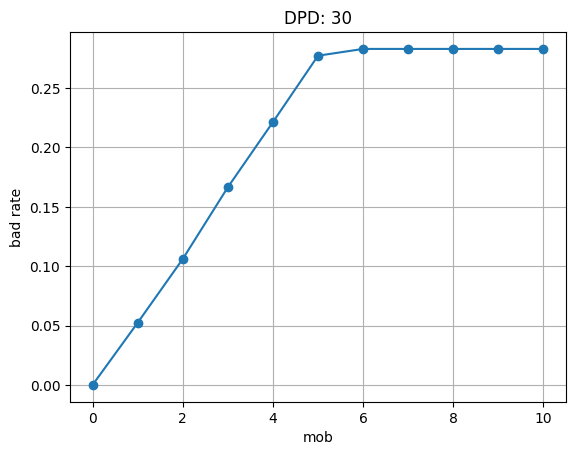

In [ ]:
# set dpd label definition
dpd = 30

# Path to the folder containing CSV files
folder_path = silver_loan_daily_directory

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)

# filter only completed loans
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# actual bads 
actual_bads_df = df.filter(col("installment_num") == 10)

# prepare for analysis
# df = df.filter(col("installment_num") < 10)

# visualise bad rate
pdf = df.toPandas()

# Group by col_A and count occurrences in col_B
grouped = pdf.groupby('mob')['dpd_flag'].mean()

# Sort the index (x-axis) of the grouped DataFrame
grouped = grouped.sort_index()

# Plotting
grouped.plot(kind='line', marker='o')

plt.title('DPD: '+ str(dpd))
plt.xlabel('mob')
plt.ylabel('bad rate')
plt.grid(True)
plt.show()


In [ ]:
df.show()

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|installments_missed|first_missed_date|dpd|dpd_flag|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|CUS_0x1011_2023_1...| CUS_0x1011|     2023-11-01|    10|             10| 10000.0| 1000.0|  1000.0|        0.0|    0.0|   2024-09-01| 10|                  0|             NULL|  0|       0|
|CUS_0x1013_2023_1...| CUS_0x1013|     2023-12-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-09-01|  9|                  0|             NULL|  0|       0|
|CUS_0x1018_2023_1...| CUS_0x1018|     2023-11-01|    1

## Build gold table for labels

In [ ]:
# create bronze datalake
gold_label_store_directory = "datamart/gold/label_store/"

if not os.path.exists(gold_label_store_directory):
    os.makedirs(gold_label_store_directory)

In [ ]:
# run gold backfill
for date_str in dates_str_lst:
    utils.data_processing_gold_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6)


loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet row count: 530
saved to: datamart/gold/label_store/gold_label_store_2023_01_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet row count: 1031
saved to: datamart/gold/label_store/gold_label_store_2023_02_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet row count: 1537
saved to: datamart/gold/label_store/gold_label_store_2023_03_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet row count: 2047
saved to: datamart/gold/label_store/gold_label_store_2023_04_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet row count: 2568
saved to: datamart/gold/label_store/gold_label_store_2023_05_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_06_01.parquet row count: 3085
saved to: datamart/gold/label_store/gold_label_store_2023_06_01.parquet
loaded from

In [ ]:
utils.data_processing_gold_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6).dtypes


loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet row count: 5531
saved to: datamart/gold/label_store/gold_label_store_2024_12_01.parquet


[('loan_id', 'string'),
 ('Customer_ID', 'string'),
 ('label', 'int'),
 ('label_def', 'string'),
 ('snapshot_date', 'date')]

## inspect label store

In [ ]:
folder_path = gold_label_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:",df.count())

df.show()

row_count: 8974
+--------------------+-----------+-----+----------+-------------+
|             loan_id|Customer_ID|label| label_def|snapshot_date|
+--------------------+-----------+-----+----------+-------------+
|CUS_0x1037_2023_0...| CUS_0x1037|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1069_2023_0...| CUS_0x1069|    0|30dpd_6mob|   2023-07-01|
|CUS_0x114a_2023_0...| CUS_0x114a|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1184_2023_0...| CUS_0x1184|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1297_2023_0...| CUS_0x1297|    1|30dpd_6mob|   2023-07-01|
|CUS_0x12fb_2023_0...| CUS_0x12fb|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1325_2023_0...| CUS_0x1325|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1341_2023_0...| CUS_0x1341|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1375_2023_0...| CUS_0x1375|    1|30dpd_6mob|   2023-07-01|
|CUS_0x13a8_2023_0...| CUS_0x13a8|    0|30dpd_6mob|   2023-07-01|
|CUS_0x13ef_2023_0...| CUS_0x13ef|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1440_2023_0...| CUS_0x1440|    0|30dpd_6mob|   2023-0

In [ ]:
df.printSchema()

root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- label_def: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

